In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os
import pandas as pd

In [2]:
years = [2008, 2009, 2010, 2011, 2012]

output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

In [3]:
years = [2008, 2009, 2010, 2011, 2012]
output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

hrdps_processed_files = []
for year in years:
    file = f"{output_dir}/HRDPS_{year}_tair_3h_with_latlon.nc"
    hrdps_processed_files.append(file)
ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")
ds_hrdps = ds_hrdps.sortby("time_counter")
print(ds_hrdps)

/tmp/ipykernel_2726599/1211250413.py:9: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")


<xarray.Dataset> Size: 12GB
Dimensions:       (time_counter: 14592, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
    nav_lat       (time_counter, y, x) float32 4GB 45.61 45.62 ... 52.37 52.37
    nav_lon       (time_counter, y, x) float32 4GB 232.7 232.7 ... 239.6 239.7
Dimensions without coordinates: y, x
Data variables:
    tair          (time_counter, y, x) float32 4GB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>


In [4]:
# Training: 2009, 2010, and 2011
ds_hrdps_train = ds_hrdps.sel(time_counter=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_hrdps_val = ds_hrdps.sel(time_counter=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_hrdps_test = ds_hrdps.sel(time_counter=slice("2012-01-01", "2012-12-31"))
print("HRDPS Training:")
print(ds_hrdps_train.time_counter.values[0],"to",ds_hrdps_train.time_counter.values[-1])
print("HRDPS Validation:")
print(ds_hrdps_val.time_counter.values[0],"to",ds_hrdps_val.time_counter.values[-1])
print("HRDPS Testing:")
print(ds_hrdps_test.time_counter.values[0],"to",ds_hrdps_test.time_counter.values[-1])

HRDPS Training:
2009-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
HRDPS Validation:
2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
HRDPS Testing:
2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [5]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_tas_files = []
for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/"f"*_{year}01_{year}12_3h_tas.nc"))
    canrcm_tas_files.append(matches[0])

print("CanRCM temperature files:")
for file in canrcm_tas_files:
    print(file)

CanRCM temperature files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_tas.nc


In [6]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
ds_canrcm = ds_canrcm.assign_coords(time=ds_canrcm.time.values - timedelta(hours=3))
print(ds_canrcm)

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    tas           (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_2726599/3930337657.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")


In [7]:
lat_hr = ds_hrdps["nav_lat"]
lon_hr = ds_hrdps["nav_lon"]
lon_hr_normalized = ((lon_hr + 180) % 360) - 180
lat_min = float(lat_hr.min())
lat_max = float(lat_hr.max())
lon_min = float(lon_hr_normalized.min())
lon_max = float(lon_hr_normalized.max())
print("HRDPS latitude range:")
print(lat_min, "to", lat_max)
print("HRDPS longitude range:")
print(lon_min, "to", lon_max)

HRDPS latitude range:
45.52116012573242 to 52.4603157043457
HRDPS longitude range:
-129.47222900390625 to -119.20327758789062


In [8]:
lat_lr = ds_canrcm["lat"]
lon_lr = ds_canrcm["lon"]
lon_lr_normalized = ((lon_lr + 180) % 360) - 180
mask_lr = ((lat_lr >= lat_min) &(lat_lr <= lat_max) &(lon_lr_normalized >= lon_min) &(lon_lr_normalized <= lon_max))
i_idx, j_idx = np.where(mask_lr.values)
i_min = i_idx.min()
i_max = i_idx.max()
j_min = j_idx.min()
j_max = j_idx.max()
print("CanRCM grid indices:")
print("rlat:", i_min, "to", i_max)
print("rlon:", j_min, "to", j_max)

CanRCM grid indices:
rlat: 161 to 200
rlon: 79 to 117


In [9]:
ds_canrcm_cut = (ds_canrcm[["tas"]].isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1)))
print(ds_canrcm_cut)

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 14600, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    tas      (time, rlat, rlon) float32 91MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ..

In [10]:
# Training: 2009, 2010, and 2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31"))
print("CanRCM Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("CanRCM Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("CanRCM Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

CanRCM Training:
2009-01-01 00:00:00 to 2011-12-31 21:00:00
CanRCM Validation:
2008-01-01 00:00:00 to 2008-12-31 21:00:00
CanRCM Testing:
2012-01-01 00:00:00 to 2012-12-31 21:00:00


In [11]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = []
    for t in ds_canrcm_split.time.values:
        canrcm_times.append(time_to_string(t))
    canrcm_times = np.array(canrcm_times)
    
    hrdps_times = []
    for t in ds_hrdps_split.time_counter.values:
        hrdps_times.append(time_to_string(t))
    hrdps_times = np.array(hrdps_times)
    
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    
    return ds_canrcm_aligned, ds_hrdps_aligned

In [12]:
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)
print("Training:")
print("CanRCM:", len(ds_canrcm_train.time))
print("HRDPS: ", len(ds_hrdps_train.time_counter))
print("Validation:")
print("CanRCM:", len(ds_canrcm_val.time))
print("HRDPS: ", len(ds_hrdps_val.time_counter))
print("Testing:")
print("CanRCM:", len(ds_canrcm_test.time))
print("HRDPS: ", len(ds_hrdps_test.time_counter))

Training:
CanRCM: 8760
HRDPS:  8760
Validation:
CanRCM: 2904
HRDPS:  2904
Testing:
CanRCM: 2912
HRDPS:  2912


In [13]:
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"
weights_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
ds_mask = xr.open_dataset(mesh_mask_file)
ds_weights = xr.open_dataset(weights_file)
print(ds_weights)
print(ds_mask)

<xarray.Dataset> Size: 24MB
Dimensions:  (lat: 266, lon: 256, y: 898, x: 398)
Dimensions without coordinates: lat, lon, y, x
Data variables:
    nav_lat  (lat, lon) float64 545kB ...
    nav_lon  (lat, lon) float64 545kB ...
    src01    (y, x) int64 3MB ...
    wgt01    (y, x) float64 3MB ...
    src02    (y, x) int64 3MB ...
    wgt02    (y, x) float64 3MB ...
    src03    (y, x) int64 3MB ...
    wgt03    (y, x) float64 3MB ...
    src04    (y, x) int64 3MB ...
    wgt04    (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO GEMLAM 2.5km Experimental pre-22-Sep-201...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO_EastCoast/NEMO_Preparation/4_weights_ATMOS/get_weight_...
    references:   https://salishsea-meopar-docs.readthedocs.io/en/latest/code...
    history:      [2022-03-21 12:04:51] Converted to netCDF4 zlib=True datase...
    comment:      
<xarray.Dataset> Size: 788MB
Dimen

In [14]:
tmask2d = ds_mask["tmask"].isel(t=0, z=0)
water_mask = tmask2d.values.astype(bool)
ny, nx = water_mask.shape
print("SalishSeaCast shape:", ny, nx)
print("Number of water cells:", water_mask.sum())

SalishSeaCast shape: 898 398
Number of water cells: 81383


In [15]:
def make_target_matrix_direct_from_hrdps_weights(da_hrdps,ds_weights,water_mask,valid_ssc_cells=None,chunk_size=100):
    da_hrdps = da_hrdps.squeeze(drop=True)
    time_dim = da_hrdps.dims[0]
    n_time = da_hrdps.sizes[time_dim]
    n_source_cells = np.prod([da_hrdps.sizes[d] for d in da_hrdps.dims[1:]])
    water_flat = water_mask.reshape(-1)
    water_indices = np.where(water_flat)[0]
    n_water = len(water_indices)
    print("Number of timestamps:", n_time)
    print("Number of SalishSeaCast water cells:", n_water)
    src_list = []
    wgt_list = []
    for n in range(1, 5):
        src_name = f"src{n:02d}"
        wgt_name = f"wgt{n:02d}"
        src_raw = ds_weights[src_name].values.reshape(-1)[water_indices].astype(np.int64)
        wgt = ds_weights[wgt_name].values.reshape(-1)[water_indices].astype(np.float32)
        valid_src = src_raw > 0
        src = np.where(valid_src, src_raw - 1, 0)
        if src.max() >= n_source_cells:
            raise ValueError(
                f"{src_name} has source index {src.max()}, but source field only has "
                f"{n_source_cells} cells. Check source grid shape/order."
            )

        wgt = np.where(valid_src, wgt, 0.0)
        src_list.append(src)
        wgt_list.append(wgt)

    X_water = np.empty((n_time, n_water), dtype=np.float32)

    for start in range(0, n_time, chunk_size):
        end = min(start + chunk_size, n_time)
        print(f"Interpolating time {start} to {end} out of {n_time}")
        source_chunk = da_hrdps.isel({time_dim: slice(start, end)}).values
        source_chunk = source_chunk.reshape(end - start, -1).astype(np.float32)
        out_chunk = np.zeros((end - start, n_water), dtype=np.float32)
        weight_sum = np.zeros((end - start, n_water), dtype=np.float32)
        for src, wgt in zip(src_list, wgt_list):
            values = source_chunk[:, src]
            valid = np.isfinite(values) & np.isfinite(wgt[None, :]) & (wgt[None, :] > 0)
            out_chunk += np.where(valid, values * wgt[None, :], 0.0)
            weight_sum += np.where(valid, wgt[None, :], 0.0)
        out_chunk = np.where(weight_sum > 0, out_chunk / weight_sum, np.nan)
        X_water[start:end, :] = out_chunk

    keep_time_initial = np.isfinite(X_water).any(axis=1)
    X_water_kept = X_water[keep_time_initial]

    if valid_ssc_cells is None:
        valid_water_cols = np.isfinite(X_water_kept).all(axis=0)

        valid_ssc_cells = np.zeros(water_flat.shape, dtype=bool)
        valid_ssc_cells[water_indices[valid_water_cols]] = True
    else:
        valid_water_cols = valid_ssc_cells[water_indices]

    X = X_water_kept[:, valid_water_cols]

    keep_time_final_inside = np.isfinite(X).all(axis=1)
    X = X[keep_time_final_inside]

    kept_indices_initial = np.where(keep_time_initial)[0]
    kept_indices_final = kept_indices_initial[keep_time_final_inside]

    keep_time = np.zeros(n_time, dtype=bool)
    keep_time[kept_indices_final] = True

    return X, keep_time, valid_ssc_cells


In [16]:
X_hrdps_train, keep_train_time, valid_ssc_cells = make_target_matrix_direct_from_hrdps_weights(
    ds_hrdps_train["tair"],
    ds_weights,
    water_mask,
    valid_ssc_cells=None,
    chunk_size=100
)

X_hrdps_val, keep_val_time, _ = make_target_matrix_direct_from_hrdps_weights(
    ds_hrdps_val["tair"],
    ds_weights,
    water_mask,
    valid_ssc_cells=valid_ssc_cells,
    chunk_size=100
)

X_hrdps_test, keep_test_time, _ = make_target_matrix_direct_from_hrdps_weights(
    ds_hrdps_test["tair"],
    ds_weights,
    water_mask,
    valid_ssc_cells=valid_ssc_cells,
    chunk_size=100
)

print("HRDPS train target matrix:", X_hrdps_train.shape)
print("HRDPS val target matrix:  ", X_hrdps_val.shape)
print("HRDPS test target matrix: ", X_hrdps_test.shape)
print("Number of valid SSC cells:", valid_ssc_cells.sum())



Number of timestamps: 8760
Number of SalishSeaCast water cells: 81383
Interpolating time 0 to 100 out of 8760
Interpolating time 100 to 200 out of 8760
Interpolating time 200 to 300 out of 8760
Interpolating time 300 to 400 out of 8760
Interpolating time 400 to 500 out of 8760
Interpolating time 500 to 600 out of 8760
Interpolating time 600 to 700 out of 8760
Interpolating time 700 to 800 out of 8760
Interpolating time 800 to 900 out of 8760
Interpolating time 900 to 1000 out of 8760
Interpolating time 1000 to 1100 out of 8760
Interpolating time 1100 to 1200 out of 8760
Interpolating time 1200 to 1300 out of 8760
Interpolating time 1300 to 1400 out of 8760
Interpolating time 1400 to 1500 out of 8760
Interpolating time 1500 to 1600 out of 8760
Interpolating time 1600 to 1700 out of 8760
Interpolating time 1700 to 1800 out of 8760
Interpolating time 1800 to 1900 out of 8760
Interpolating time 1900 to 2000 out of 8760


/tmp/ipykernel_2726599/2885168273.py:44: RuntimeWarning: invalid value encountered in divide
  out_chunk = np.where(weight_sum > 0, out_chunk / weight_sum, np.nan)


Interpolating time 2000 to 2100 out of 8760
Interpolating time 2100 to 2200 out of 8760
Interpolating time 2200 to 2300 out of 8760
Interpolating time 2300 to 2400 out of 8760
Interpolating time 2400 to 2500 out of 8760
Interpolating time 2500 to 2600 out of 8760
Interpolating time 2600 to 2700 out of 8760
Interpolating time 2700 to 2800 out of 8760
Interpolating time 2800 to 2900 out of 8760
Interpolating time 2900 to 3000 out of 8760
Interpolating time 3000 to 3100 out of 8760
Interpolating time 3100 to 3200 out of 8760
Interpolating time 3200 to 3300 out of 8760
Interpolating time 3300 to 3400 out of 8760
Interpolating time 3400 to 3500 out of 8760
Interpolating time 3500 to 3600 out of 8760
Interpolating time 3600 to 3700 out of 8760
Interpolating time 3700 to 3800 out of 8760
Interpolating time 3800 to 3900 out of 8760
Interpolating time 3900 to 4000 out of 8760
Interpolating time 4000 to 4100 out of 8760
Interpolating time 4100 to 4200 out of 8760
Interpolating time 4200 to 4300 

In [17]:
ds_canrcm_train_final = ds_canrcm_train.isel(time=keep_train_time)
ds_canrcm_val_final = ds_canrcm_val.isel(time=keep_val_time)
ds_canrcm_test_final = ds_canrcm_test.isel(time=keep_test_time)

In [18]:
X_canrcm_train = ds_canrcm_train_final["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_train_final.time), -1).astype(np.float32)
X_canrcm_val = ds_canrcm_val_final["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_val_final.time), -1).astype(np.float32)
X_canrcm_test = ds_canrcm_test_final["tas"].squeeze(drop=True).values.reshape(len(ds_canrcm_test_final.time), -1).astype(np.float32)

print("CanRCM train input matrix:", X_canrcm_train.shape)
print("CanRCM val input matrix:  ", X_canrcm_val.shape)
print("CanRCM test input matrix: ", X_canrcm_test.shape)

print("HRDPS train target matrix:", X_hrdps_train.shape)
print("HRDPS val target matrix:  ", X_hrdps_val.shape)
print("HRDPS test target matrix: ", X_hrdps_test.shape)

CanRCM train input matrix: (8684, 1560)
CanRCM val input matrix:   (2842, 1560)
CanRCM test input matrix:  (2912, 1560)
HRDPS train target matrix: (8684, 81383)
HRDPS val target matrix:   (2842, 81383)
HRDPS test target matrix:  (2912, 81383)


In [19]:
max_hrdps_pcs_for_search = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs_for_search,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)

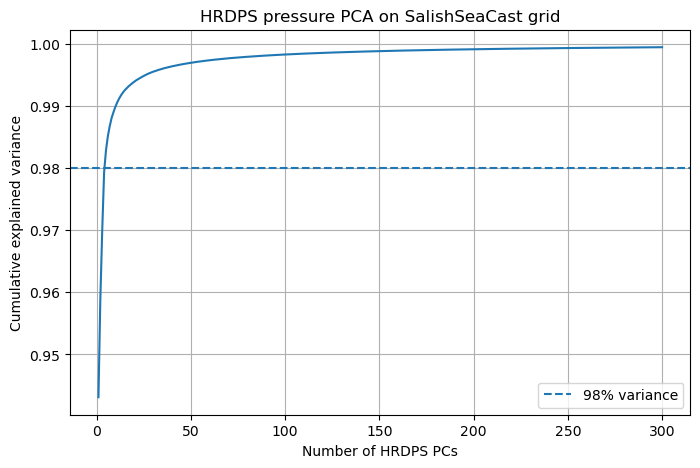

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(0.98, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS pressure PCA on SalishSeaCast grid")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= 0.98) + 1
print("Number of HRDPS PCs needed for 98% variance:",n_hrdps_pcs)

Number of HRDPS PCs needed for 98% variance: 5


In [22]:
hrdps_val_scores_all = pca_hrdps.transform(X_hrdps_val)
hrdps_test_scores_all = pca_hrdps.transform(X_hrdps_test)
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = hrdps_val_scores_all[:, :n_hrdps_pcs]
hrdps_test_scores = hrdps_test_scores_all[:, :n_hrdps_pcs]

In [23]:
max_canrcm_pcs_for_search = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs_for_search)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

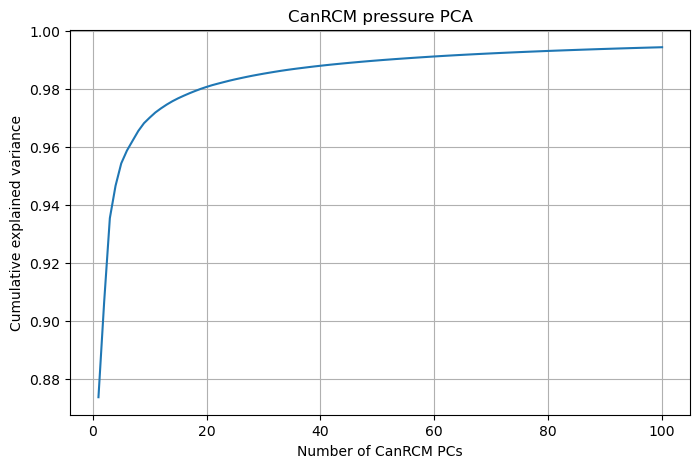

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM pressure PCA")
plt.grid(True)
plt.show()

In [25]:
results = []
for k in range(1, max_canrcm_pcs_for_search + 1):
    X_train_k = canrcm_train_scores_all[:, :k]
    X_val_k = canrcm_val_scores_all[:, :k]
    model_k = LinearRegression()
    model_k.fit(X_train_k, hrdps_train_scores)
    hrdps_val_scores_pred = model_k.predict(X_val_k)
    val_r2_uniform = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="uniform_average")
    val_r2_variance_weighted = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="variance_weighted")
    results.append(
        {
            "n_canrcm_pcs": k,
            "val_r2_uniform": val_r2_uniform,
            "val_r2_variance_weighted": val_r2_variance_weighted,
        }
    )

results_df = pd.DataFrame(results)
results_df.head()

,n_canrcm_pcs,val_r2_uniform,val_r2_variance_weighted
0,1,0.150397,0.878201
1,2,0.206981,0.880583
2,3,0.252806,0.900894
3,4,0.293195,0.910340
4,5,0.292940,0.914742


In [26]:
best_row = results_df.loc[results_df["val_r2_variance_weighted"].idxmax()]
n_canrcm_pcs = int(best_row["n_canrcm_pcs"])
print("Best number of CanRCM PCs:")
print(n_canrcm_pcs)
print("Best validation result:")
print(best_row)

Best number of CanRCM PCs:
88
Best validation result:
n_canrcm_pcs                88.000000
val_r2_uniform               0.303225
val_r2_variance_weighted     0.952909
Name: 87, dtype: float64


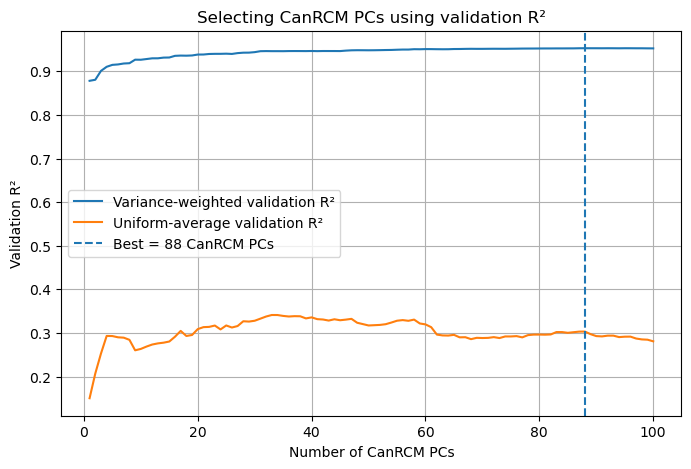

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(
    results_df["n_canrcm_pcs"],
    results_df["val_r2_variance_weighted"],
    label="Variance-weighted validation R²"
)
plt.plot(
    results_df["n_canrcm_pcs"],
    results_df["val_r2_uniform"],
    label="Uniform-average validation R²"
)
plt.axvline(
    n_canrcm_pcs,
    linestyle="--",
    label=f"Best = {n_canrcm_pcs} CanRCM PCs"
)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation R²")
plt.title("Selecting CanRCM PCs using validation R²")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
final_model = LinearRegression()

final_model.fit(
    canrcm_train_scores_all[:, :n_canrcm_pcs],
    hrdps_train_scores
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float32](5, 88)","[[ 4.55, 0.19,-3.85,...,-2.45,-2.87, 7.19], [ 0.12, 1.05, 0.96,...,-0.82, 1.36,-2.48], [ 0.03,-0.38,-0.06,..., 0.45, 0.01, 0.3 ], [ 0.04, 0.18, 0.91,..., 3.91, 1.52, 0.12], [ 0.01,-0.71, 0.17,...,-0.79, 0.32, 0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float32](5,)","[-0.01,-0. , 0.01, 0.01,-0. ]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,88
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,88
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float32](88,)","[25043.19, 4853.64, 4556.86,..., 223.04, 221.47, 219.2 ]"


In [29]:
hrdps_test_scores_pred = final_model.predict(
    canrcm_test_scores_all[:, :n_canrcm_pcs]
)

In [30]:
def inverse_from_selected_pcs(selected_scores, pca_object, n_selected_pcs):
    full_scores = np.zeros(
        (selected_scores.shape[0], pca_object.n_components_),
        dtype=np.float32
    )

    full_scores[:, :n_selected_pcs] = selected_scores

    reconstructed = pca_object.inverse_transform(full_scores)

    return reconstructed

In [31]:
X_hrdps_test_pred = inverse_from_selected_pcs(
    hrdps_test_scores_pred,
    pca_hrdps,
    n_hrdps_pcs
)

print("Predicted HRDPS test matrix:")
print(X_hrdps_test_pred.shape)

Predicted HRDPS test matrix:
(2912, 81383)


In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
test_rmse = np.sqrt(
    mean_squared_error(
        X_hrdps_test.ravel(),
        X_hrdps_test_pred.ravel()
    )
)

test_mae = mean_absolute_error(
    X_hrdps_test.ravel(),
    X_hrdps_test_pred.ravel()
)

test_bias = np.mean(X_hrdps_test_pred - X_hrdps_test)

test_r2_grid = r2_score(
    X_hrdps_test.ravel(),
    X_hrdps_test_pred.ravel()
)

test_r2_pc = r2_score(
    hrdps_test_scores,
    hrdps_test_scores_pred,
    multioutput="variance_weighted"
)

print("Final test metrics on SalishSeaCast water grid:")
print("RMSE:", test_rmse)
print("MAE: ", test_mae)
print("Bias:", test_bias)
print("Grid-cell flattened R²:", test_r2_grid)
print("PC-space variance-weighted R²:", test_r2_pc)

Final test metrics on SalishSeaCast water grid:
RMSE: 2.0211431390355457
MAE:  1.4421048164367676
Bias: 0.26636806
Grid-cell flattened R²: 0.8512201905250549
PC-space variance-weighted R²: 0.8800013065338135


In [33]:
time_test = ds_hrdps_test.time_counter.values[keep_test_time]

print("Number of test timestamps:", len(time_test))
print("Prediction matrix shape:", X_hrdps_test_pred.shape)
print("Actual matrix shape:", X_hrdps_test.shape)

Number of test timestamps: 2912
Prediction matrix shape: (2912, 81383)
Actual matrix shape: (2912, 81383)


In [34]:
def vector_to_ssc_map(vector, name):
    full = np.full(ny * nx, np.nan, dtype=np.float32)
    full[valid_ssc_cells] = vector.astype(np.float32)
    data_2d = full.reshape(ny, nx)
    da = xr.DataArray(
        data_2d,
        dims=("y", "x"),
        coords={
            "nav_lat": (("y", "x"), ds_mask["nav_lat"].values),
            "nav_lon": (("y", "x"), ds_mask["nav_lon"].values),
        },
        name=name
    )
    return da

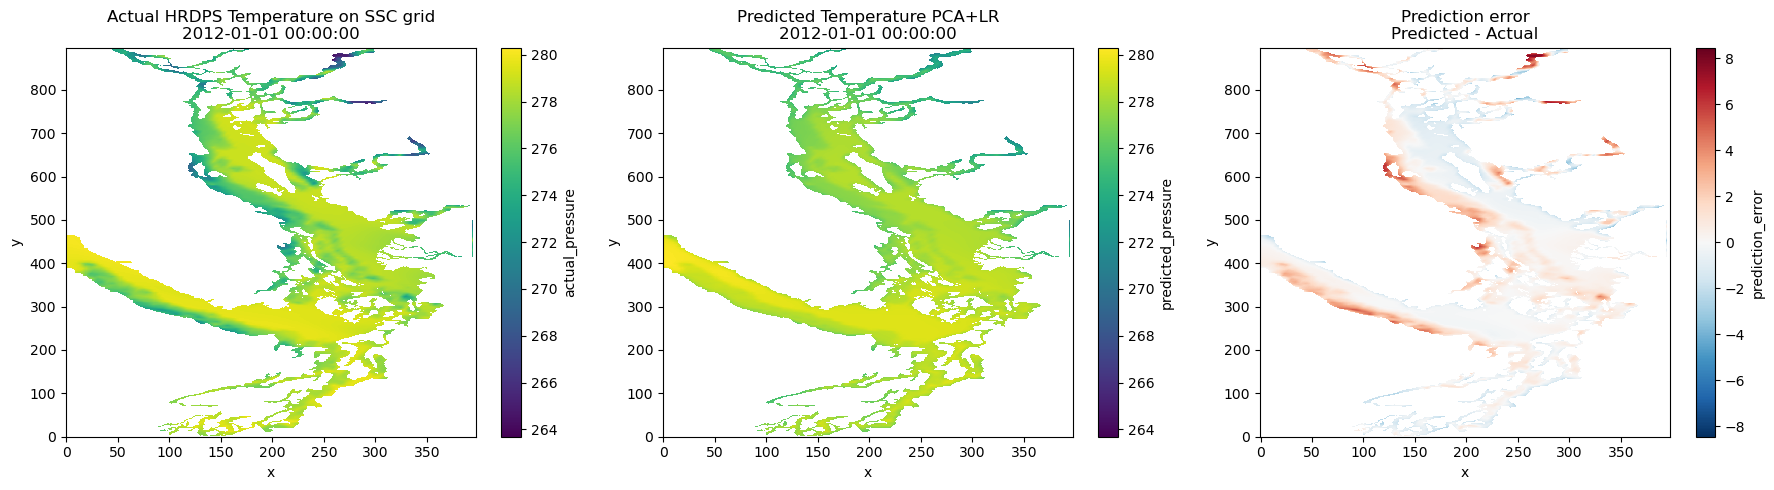

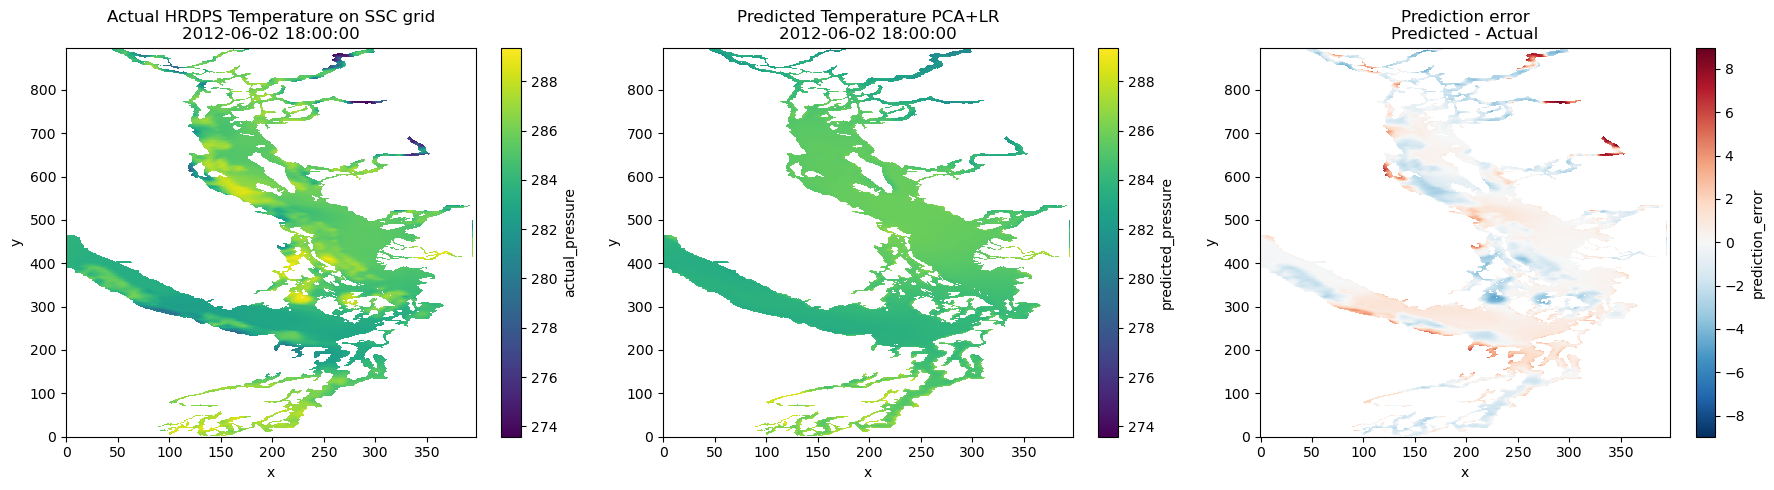

In [35]:
plot_indices = [0,1222]

for plot_index in plot_indices:

    actual_map = vector_to_ssc_map(
        X_hrdps_test[plot_index],
        "actual_pressure"
    )

    pred_map = vector_to_ssc_map(
        X_hrdps_test_pred[plot_index],
        "predicted_pressure"
    )

    error_map = pred_map - actual_map
    error_map = error_map.rename("prediction_error")

    plot_time = pd.to_datetime(time_test[plot_index])

    vmin = min(float(actual_map.min()), float(pred_map.min()))
    vmax = max(float(actual_map.max()), float(pred_map.max()))

    err_abs = float(np.nanmax(np.abs(error_map.values)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    actual_map.plot(
        ax=axes[0],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title(f"Actual HRDPS Temperature on SSC grid\n{plot_time}")

    pred_map.plot(
        ax=axes[1],
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title(f"Predicted Temperature PCA+LR\n{plot_time}")

    error_map.plot(
    ax=axes[2],
    vmin=-err_abs,
    vmax=err_abs,
    cmap="RdBu_r"
    )
    axes[2].set_title("Prediction error\nPredicted - Actual")

    plt.tight_layout()
    plt.show()

In [36]:
X_hrdps_val_pred = inverse_from_selected_pcs(
    hrdps_val_scores_pred,
    pca_hrdps,
    n_hrdps_pcs
)

print("Predicted HRDPS validation matrix:")
print(X_hrdps_test_pred.shape)

Predicted HRDPS validation matrix:
(2912, 81383)


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_rmse = np.sqrt(
    mean_squared_error(
        X_hrdps_val.ravel(),
        X_hrdps_val_pred.ravel()
    )
)

val_mae = mean_absolute_error(
    X_hrdps_val.ravel(),
    X_hrdps_val_pred.ravel()
)

val_bias = np.mean(X_hrdps_val_pred - X_hrdps_val)

val_r2_grid = r2_score(
    X_hrdps_val.ravel(),
    X_hrdps_val_pred.ravel()
)

val_r2_pc = r2_score(
    hrdps_val_scores,
    hrdps_val_scores_pred,
    multioutput="variance_weighted"
)

print("Validation metrics on SalishSeaCast water grid:")
print("RMSE:", val_rmse)
print("MAE: ", val_mae)
print("Bias:", val_bias)
print("Grid-cell flattened R²:", val_r2_grid)
print("PC-space variance-weighted R²:", val_r2_pc)

time_val = ds_hrdps_val.time_counter.values[keep_val_time]

print("Number of validation timestamps:", len(time_val))
print("Prediction matrix shape:", X_hrdps_val_pred.shape)
print("Actual matrix shape:", X_hrdps_val.shape)

Validation metrics on SalishSeaCast water grid:
RMSE: 1.1723677552887348
MAE:  0.8991142511367798
Bias: -0.17626673
Grid-cell flattened R²: 0.9395134449005127
PC-space variance-weighted R²: 0.9525247812271118
Number of validation timestamps: 2842
Prediction matrix shape: (2842, 81383)
Actual matrix shape: (2842, 81383)


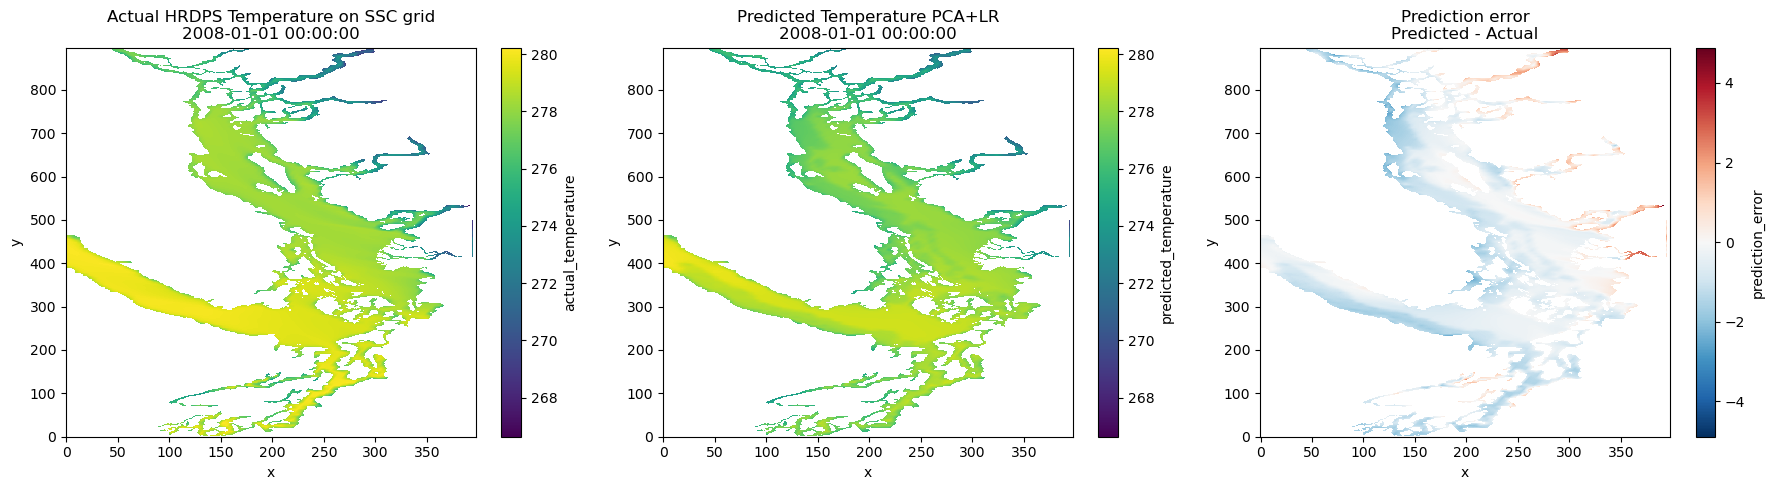

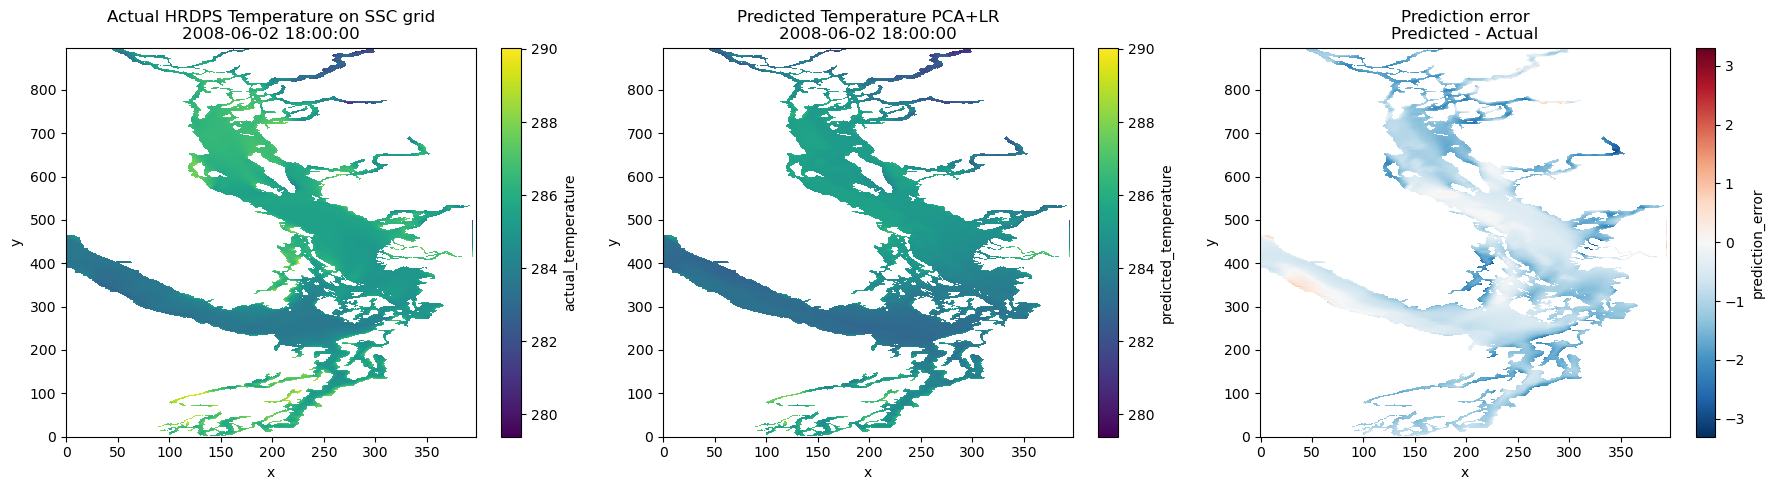

In [38]:
plot_indices = [0, 1222]

for plot_index in plot_indices:

    actual_map = vector_to_ssc_map(
        X_hrdps_val[plot_index],
        "actual_temperature"
    )

    pred_map = vector_to_ssc_map(
        X_hrdps_val_pred[plot_index],
        "predicted_temperature"
    )

    error_map = pred_map - actual_map
    error_map = error_map.rename("prediction_error")

    plot_time = pd.to_datetime(time_val[plot_index])

    vmin = min(float(actual_map.min()), float(pred_map.min()))
    vmax = max(float(actual_map.max()), float(pred_map.max()))

    err_abs = float(np.nanmax(np.abs(error_map.values)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    actual_map.plot(
        ax=axes[0],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title(f"Actual HRDPS Temperature on SSC grid\n{plot_time}")

    pred_map.plot(
        ax=axes[1],
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title(f"Predicted Temperature PCA+LR\n{plot_time}")

    error_map.plot(
        ax=axes[2],
        vmin=-err_abs,
        vmax=err_abs,
        cmap="RdBu_r"
    )
    axes[2].set_title("Prediction error\nPredicted - Actual")

    plt.tight_layout()
    plt.show()

In [39]:
def make_hrdps_used_mask_from_ssc_water(da_hrdps, ds_weights, water_mask):
    da_hrdps = da_hrdps.squeeze(drop=True)
    time_dim = da_hrdps.dims[0]
    spatial_dims = da_hrdps.dims[1:]
    hrdps_shape = tuple(da_hrdps.sizes[d] for d in spatial_dims)
    n_hrdps_cells = np.prod(hrdps_shape)
    water_flat = water_mask.reshape(-1)
    water_indices = np.where(water_flat)[0]
    mask_hrdps_flat = np.zeros(n_hrdps_cells, dtype=bool)

    for n in range(1, 5):
        src_name = f"src{n:02d}"
        src_raw = ds_weights[src_name].values.reshape(-1)[water_indices].astype(np.int64)
        valid_src = src_raw > 0
        src = src_raw[valid_src] - 1
        if src.max() >= n_hrdps_cells:
            raise ValueError(
                f"{src_name} has source index {src.max()}, but HRDPS only has "
                f"{n_hrdps_cells} cells. Check grid shape/order."
            )
        mask_hrdps_flat[src] = True
    mask_hrdps_2d = mask_hrdps_flat.reshape(hrdps_shape)
    return mask_hrdps_2d, mask_hrdps_flat

In [40]:
mask_HRDPS_2d, mask_HRDPS_flat = make_hrdps_used_mask_from_ssc_water(
    ds_hrdps_train["tair"],
    ds_weights,
    water_mask
)

print("HRDPS mask shape:", mask_HRDPS_2d.shape)
print("Number of HRDPS cells used by SSC water cells:", mask_HRDPS_2d.sum())
print("Total HRDPS cells:", mask_HRDPS_2d.size)

HRDPS mask shape: (266, 256)
Number of HRDPS cells used by SSC water cells: 4731
Total HRDPS cells: 68096


In [41]:
def make_hrdps_matrix_from_used_mask(da_hrdps, mask_HRDPS_flat):
    da_hrdps = da_hrdps.squeeze(drop=True)
    time_dim = da_hrdps.dims[0]
    n_time = da_hrdps.sizes[time_dim]
    hrdps_flat = da_hrdps.values.reshape(n_time, -1).astype(np.float32)
    X = hrdps_flat[:, mask_HRDPS_flat]
    return X

In [42]:
X_hrdps_train_raw = make_hrdps_matrix_from_used_mask(ds_hrdps_train["tair"],mask_HRDPS_flat)
X_hrdps_val_raw = make_hrdps_matrix_from_used_mask(ds_hrdps_val["tair"],mask_HRDPS_flat)
X_hrdps_test_raw = make_hrdps_matrix_from_used_mask(ds_hrdps_test["tair"],mask_HRDPS_flat)
print("Raw HRDPS train matrix:", X_hrdps_train_raw.shape)
print("Raw HRDPS val matrix:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS test matrix: ", X_hrdps_test_raw.shape)

Raw HRDPS train matrix: (8760, 4731)
Raw HRDPS val matrix:   (2904, 4731)
Raw HRDPS test matrix:  (2912, 4731)


In [43]:
def make_canrcm_matrix(da_canrcm):
    da_canrcm = da_canrcm.squeeze(drop=True)
    time_dim = da_canrcm.dims[0]
    n_time = da_canrcm.sizes[time_dim]
    X = da_canrcm.values.reshape(n_time, -1).astype(np.float32)
    return X

In [44]:
X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["tas"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["tas"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["tas"])
print("Raw CanRCM train matrix:", X_canrcm_train_raw.shape)
print("Raw CanRCM val matrix:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test matrix: ", X_canrcm_test_raw.shape)

Raw CanRCM train matrix: (8760, 1560)
Raw CanRCM val matrix:   (2904, 1560)
Raw CanRCM test matrix:  (2912, 1560)


In [45]:
# Keep HRDPS cells that are valid for most training timestamps
valid_fraction = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_hrdps_cols = valid_fraction > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_hrdps_cols]
X_hrdps_val = X_hrdps_val_raw[:, valid_hrdps_cols]
X_hrdps_test = X_hrdps_test_raw[:, valid_hrdps_cols]

# Fill remaining NaNs using training column mean
hrdps_col_mean = np.nanmean(X_hrdps_train, axis=0)

inds = np.where(~np.isfinite(X_hrdps_train))
X_hrdps_train[inds] = np.take(hrdps_col_mean, inds[1])

inds = np.where(~np.isfinite(X_hrdps_val))
X_hrdps_val[inds] = np.take(hrdps_col_mean, inds[1])

inds = np.where(~np.isfinite(X_hrdps_test))
X_hrdps_test[inds] = np.take(hrdps_col_mean, inds[1])

# Update HRDPS mask for plotting
used_hrdps_indices = np.where(mask_HRDPS_flat)[0]
valid_used_hrdps_indices = used_hrdps_indices[valid_hrdps_cols]

mask_HRDPS_flat_valid = np.zeros_like(mask_HRDPS_flat, dtype=bool)
mask_HRDPS_flat_valid[valid_used_hrdps_indices] = True

mask_HRDPS_2d_valid = mask_HRDPS_flat_valid.reshape(mask_HRDPS_2d.shape)

print("Final number of valid HRDPS target cells:", mask_HRDPS_flat_valid.sum())
print("Final HRDPS train matrix:", X_hrdps_train.shape)
print("Final HRDPS val matrix:  ", X_hrdps_val.shape)
print("Final HRDPS test matrix: ", X_hrdps_test.shape)

Final number of valid HRDPS target cells: 4731
Final HRDPS train matrix: (8760, 4731)
Final HRDPS val matrix:   (2904, 4731)
Final HRDPS test matrix:  (2912, 4731)


In [46]:
used_hrdps_indices = np.where(mask_HRDPS_flat)[0]
valid_used_hrdps_indices = used_hrdps_indices[valid_hrdps_cols]

mask_HRDPS_flat_valid = np.zeros_like(mask_HRDPS_flat, dtype=bool)
mask_HRDPS_flat_valid[valid_used_hrdps_indices] = True

mask_HRDPS_2d_valid = mask_HRDPS_flat_valid.reshape(mask_HRDPS_2d.shape)

print("Final number of valid HRDPS target cells:", mask_HRDPS_flat_valid.sum())

Final number of valid HRDPS target cells: 4731


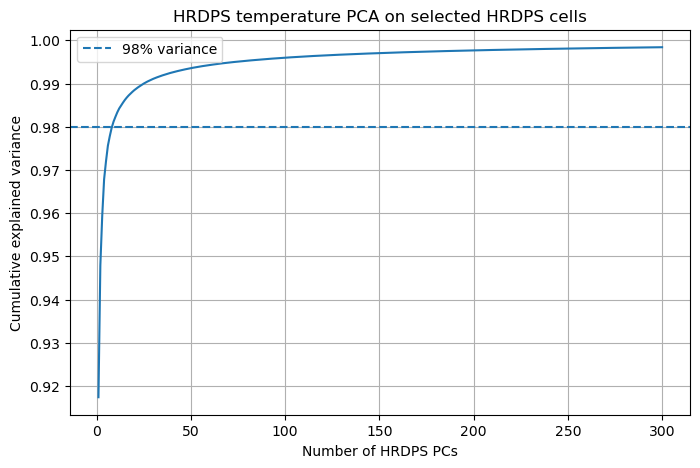

Number of HRDPS PCs needed for 98% variance: 9


In [47]:
hrdps_variance_threshold = 0.98

max_hrdps_pcs_for_search = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs_for_search,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS temperature PCA on selected HRDPS cells")
plt.legend()
plt.grid(True)
plt.show()
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= hrdps_variance_threshold) + 1
print(f"Number of HRDPS PCs needed for 98% variance: {n_hrdps_pcs}")

In [48]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]
print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (8760, 9)
HRDPS val scores:   (2904, 9)
HRDPS test scores:  (2912, 9)


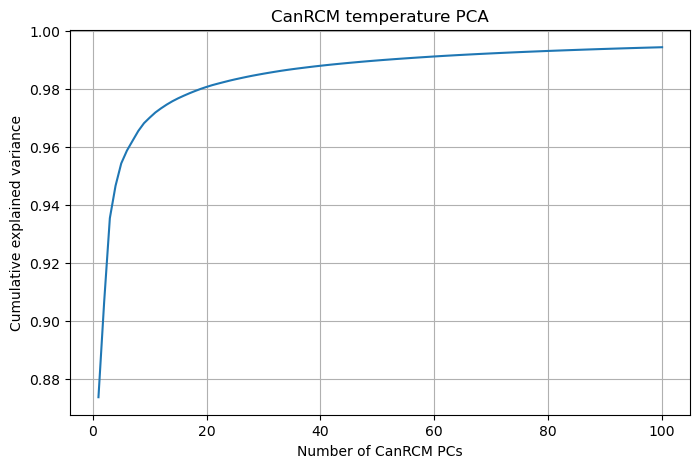

In [49]:
max_canrcm_pcs_for_search = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs_for_search,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM temperature PCA")
plt.grid(True)
plt.show()

In [50]:
canrcm_pc_candidates = range(1, max_canrcm_pcs_for_search + 1)

val_r2_scores = []

for n_canrcm_pcs in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:, :n_canrcm_pcs]
    X_val_pc = canrcm_val_scores_all[:, :n_canrcm_pcs]
    model = LinearRegression()
    model.fit(X_train_pc, hrdps_train_scores)
    hrdps_val_scores_pred = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)

val_r2_scores = np.array(val_r2_scores)

best_index = np.argmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]

print("Best number of CanRCM PCs based on validation R²:")
print(n_canrcm_pcs)
print("Best validation R²:")
print(val_r2_scores[best_index])

ValueError: Found input variables with inconsistent numbers of samples: [8684, 8760]

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates), val_r2_scores, marker="o")
plt.axvline(n_canrcm_pcs, linestyle="--", label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation R²")
plt.title("Choosing CanRCM PCs using validation R²")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_train_pc_final = canrcm_train_scores_all[:, :n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:, :n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:, :n_canrcm_pcs]

lr_model = LinearRegression()
lr_model.fit(X_train_pc_final, hrdps_train_scores)

hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)

print("Predicted HRDPS train scores:", hrdps_train_scores_pred.shape)
print("Predicted HRDPS val scores:  ", hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores: ", hrdps_test_scores_pred.shape)

In [ ]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores, pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed

In [ ]:
X_hrdps_train_pred = inverse_from_selected_hrdps_pcs(hrdps_train_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred,pca_hrdps,n_hrdps_pcs)
print("Predicted HRDPS train matrix:", X_hrdps_train_pred.shape)
print("Predicted HRDPS val matrix:  ", X_hrdps_val_pred.shape)
print("Predicted HRDPS test matrix: ", X_hrdps_test_pred.shape)

In [ ]:
def calculate_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))
    mae = mean_absolute_error(y_true.ravel(), y_pred.ravel())
    bias = np.mean(y_pred - y_true)
    r2 = r2_score(y_true,y_pred,multioutput="variance_weighted")

    print(f"{label} metrics")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R²:  ", r2)
    print()

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "R2": r2
    }

In [ ]:
train_metrics = calculate_metrics(X_hrdps_train,X_hrdps_train_pred,"Train")
val_metrics = calculate_metrics(X_hrdps_val,X_hrdps_val_pred,"Validation")
test_metrics = calculate_metrics(X_hrdps_test,X_hrdps_test_pred,"Test")

In [ ]:
def vector_to_hrdps_map(vector, mask_HRDPS_flat_valid, hrdps_shape, name):
    full = np.full(mask_HRDPS_flat_valid.shape, np.nan, dtype=np.float32)
    full[mask_HRDPS_flat_valid] = vector.astype(np.float32)
    data_2d = full.reshape(hrdps_shape)
    da = xr.DataArray(data_2d,dims=("y", "x"),name=name)
    return da

In [ ]:
hrdps_da_example = ds_hrdps_test["tair"].squeeze(drop=True)
hrdps_shape = tuple(hrdps_da_example.sizes[d] for d in hrdps_da_example.dims[1:])

print("HRDPS spatial shape:", hrdps_shape)

In [ ]:
def plot_hrdps_actual_pred_error(
    time_index,
    X_actual,
    X_pred,
    mask_HRDPS_flat_valid,
    hrdps_shape,
    times=None
):
    actual_vector = X_actual[time_index]
    pred_vector = X_pred[time_index]
    error_vector = pred_vector - actual_vector

    actual_map = vector_to_hrdps_map(
        actual_vector,
        mask_HRDPS_flat_valid,
        hrdps_shape,
        "Actual HRDPS"
    )

    pred_map = vector_to_hrdps_map(
        pred_vector,
        mask_HRDPS_flat_valid,
        hrdps_shape,
        "Predicted HRDPS"
    )

    error_map = vector_to_hrdps_map(
        error_vector,
        mask_HRDPS_flat_valid,
        hrdps_shape,
        "Prediction Error"
    )

    vmin = np.nanmin([actual_map.values, pred_map.values])
    vmax = np.nanmax([actual_map.values, pred_map.values])

    err_abs = np.nanmax(np.abs(error_map.values))

    if times is not None:
        plot_time = pd.to_datetime(times[time_index])
        title_suffix = str(plot_time)
    else:
        title_suffix = f"time index {time_index}"

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    p0 = axes[0].pcolormesh(
        actual_map.values,
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title(f"Actual HRDPS\n{title_suffix}")
    plt.colorbar(p0, ax=axes[0])

    p1 = axes[1].pcolormesh(
        pred_map.values,
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title(f"Predicted HRDPS\n{title_suffix}")
    plt.colorbar(p1, ax=axes[1])

    p2 = axes[2].pcolormesh(
        error_map.values,
        shading="auto",
        vmin=-err_abs,
        vmax=err_abs,
        cmap="RdBu_r"
    )
    axes[2].set_title(f"Error: Predicted - Actual\n{title_suffix}")
    plt.colorbar(p2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.tight_layout()
    plt.show()

In [ ]:
test_times_all = pd.to_datetime(ds_hrdps_test["time_counter"].values)
test_times = test_times_all[keep_test_time]

In [ ]:
plot_hrdps_actual_pred_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_pred=X_hrdps_test_pred,
    mask_HRDPS_flat_valid=mask_HRDPS_flat_valid,
    hrdps_shape=hrdps_shape,
    times=test_times
)

In [ ]:
plot_hrdps_actual_pred_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_pred=X_hrdps_test_pred,
    mask_HRDPS_flat_valid=mask_HRDPS_flat_valid,
    hrdps_shape=hrdps_shape,
    times=test_times
)